#### Summary: 
In this notebook we will perform multiple comparisons between the links from different methods (all in a common format). These comparisons include: 
- Comparison between distribution of link distances by method (overlay andmulti-panel histograms)
- Basic overlap between all links sets (Upset plot) 
- Output link overlaps to multiple files for further use
- Maybe more will be added!

# 1. Basic Preparation

In [1]:
# Import necessary libraries
suppressMessages(library(tidyverse))
suppressMessages(library(stringr))
suppressMessages(library(data.table))
suppressMessages(library(grid))

suppressMessages(library(tictoc))
suppressMessages(library(UpSetR))
suppressMessages(library(cicero))
suppressMessages(library(pheatmap))
suppressMessages(library(RColorBrewer))

In [2]:
# Define celltypes list
celltypes <- c('beta','alpha','delta','gamma','ductal','acinar')

# Define colors for each celltype (same order as celltypes)
colors <- c('#3F98E0', '#F51646', '#E39E14', '#A1D99B', '#09850B','#F5DE6C')

In [3]:
set.seed(8)

### Define necessary reference files

In [4]:
# read in the gene coords ref file
ref_df <- read.table('non-diabetic-islet-multiomics/references/gene_coords.gencodev32.hg38.bed', sep='\t', header=FALSE) #read in gene coords ref
promoter_df <- read.table('non-diabetic-islet-multiomics/references/gene_coords.gencodev32.hg38.TSS500bp.bed', sep='\t', header=FALSE) #read in promoter ref

### Establish file naming practices for links files

In [5]:
links_dir <- "/dir/with/processed/cRE-gene/links"

In [6]:
# SMORES method links files = sm_prefix + celltype + '/' + celltype + sm_suffix
sm_prefix1 <- file.path(links_dir,'SMORES/')
sm_suffix1 <- '_mapped_links.bedpe'
sm_prefix2 <- paste0(sm_prefix1,'nonsig_links/')
sm_suffix2 <- '_mapped_links.bedpe'

# SCARlink method links files = sl_prefix + celltype + '/' + celltype + sl_suffix
sl_prefix <- file.path(links_dir,'SCARlink/')
sl_suffix1 <- '_mapped_SIG_links.bedpe'
sl_suffix2 <- '_mapped_BG_links.bedpe'

# ABC links = abc_prefix + '/' + celltype + sl_suffix
abc_prefix1 <- file.path(links_dir,'ABC/')
abc_suffix1 <- '_mapped_links.bedpe'
abc_prefix2 <- paste0(abc_prefix1,'nonsig_links/')
abc_suffix2 <- '_mapped_links.bedpe'

# Processed Cicero links
cic_prefix1 <- file.path(links_dir,'Cicero/')
cic_prefix2 <- paste0(cic_prefix1, 'nonsig_links/')
cic_suffix1 <- '_links.CP_reformat.bedpe'
cic_suffix2 <- '_links.final_filt.bedpe'

In [7]:
overlap_prefix <- file.path(links_dir,'combined/')
overlap_suffix1 <- '_all_methods_sig_links.bedpe'
overlap_suffix2 <- '_all_methods_bg_links.bedpe'

# 2. Compare Methods Distribution of Distances

### Functions

In [13]:
### Function to calculate link distances from a bedpe style dataframe row
calc_link_distance <- function(link_df_row){
    CRE_start <- as.integer(link_df_row[2])
    CRE_end <- as.integer(link_df_row[3])
    gene_start <- as.integer(link_df_row[5])
    CRE_center <- CRE_start + (CRE_end - CRE_start)/2
    distance <- abs(CRE_center - gene_start)
    return(distance)
}

### Function to plot overlay histograms of distances from 3 methods (SMORES, ABC, Cicero)
### Instead of overlaying histograms, this puts them in separate stacked plots
compare_distance_distribs <- function(celltype, sm_fp, sl_fp, abc_fp, cicero_fp, method_colors, x_lims){
    # Read in link sets from each method
    sm_df <- read.table(sm_fp, sep='\t')
    sl_df <- read.table(sl_fp, sep='\t')
    abc_df <- read.table(abc_fp, sep='\t')
    cic_df <- read.table(cicero_fp, sep='\t')
    
    # Add column of link distances to each df
    distances0 <- unlist(apply(sm_df, 1, calc_link_distance))
    distances1 <- unlist(apply(sl_df, 1, calc_link_distance))
    distances2 <- unlist(apply(abc_df, 1, calc_link_distance))
    distances3 <- unlist(apply(cic_df, 1, calc_link_distance))
    
    # Make ggplot2 formatted dataframe
    data <- data.frame(distance = c(distances0,distances1, distances2, distances3),
                       method = c(rep('SMORES', dim(sm_df)[1]), rep('SCARlink', dim(sl_df)[1]), rep('ABC', dim(abc_df)[1]), rep('Cicero', dim(cic_df)[1])))    
    
    # Make overlay histogram
    options(repr.plot.width = 10, repr.plot.height = 10)
    theme_set(theme_classic())
    p1 <- ggplot(data=data, aes(x=distance, fill=method)) +
            geom_histogram(position="identity", bins = 200) +     
            scale_fill_manual(values=method_colors) + 
            xlim(x_lims) + 
            labs(x='cRE-gene Link Distance', y='Number of Links',
                 title=paste(str_to_title(celltype),' cell links',sep='')) +     
            facet_wrap(~ method, nrow=4, ncol=1, strip.position='right') +
            theme(plot.title=element_text(size=20, hjust=0.5),
                  axis.text.x=element_text(size=20, vjust=0.5),
                  axis.text.y=element_text(size=20, vjust=0.5),
                  axis.title.x = element_text(size=20, vjust=-0.35),
                  axis.title.y = element_text(size=20, vjust=0.5),
                  legend.position = 'none')
    print(p1)
}

### Plotting

In [15]:
method_colors <- c('SMORES'='#B35D91',
                   'SCARlink'='#56B05C',
                   'ABC'='#4568A8', 
                   'Cicero'='#D8C45E')

Warning message:
"Removed 2 rows containing non-finite values (`stat_bin()`)."
Warning message:
"Removed 8 rows containing missing values (`geom_bar()`)."
Warning message:
"Removed 3 rows containing non-finite values (`stat_bin()`)."
Warning message:
"Removed 8 rows containing missing values (`geom_bar()`)."


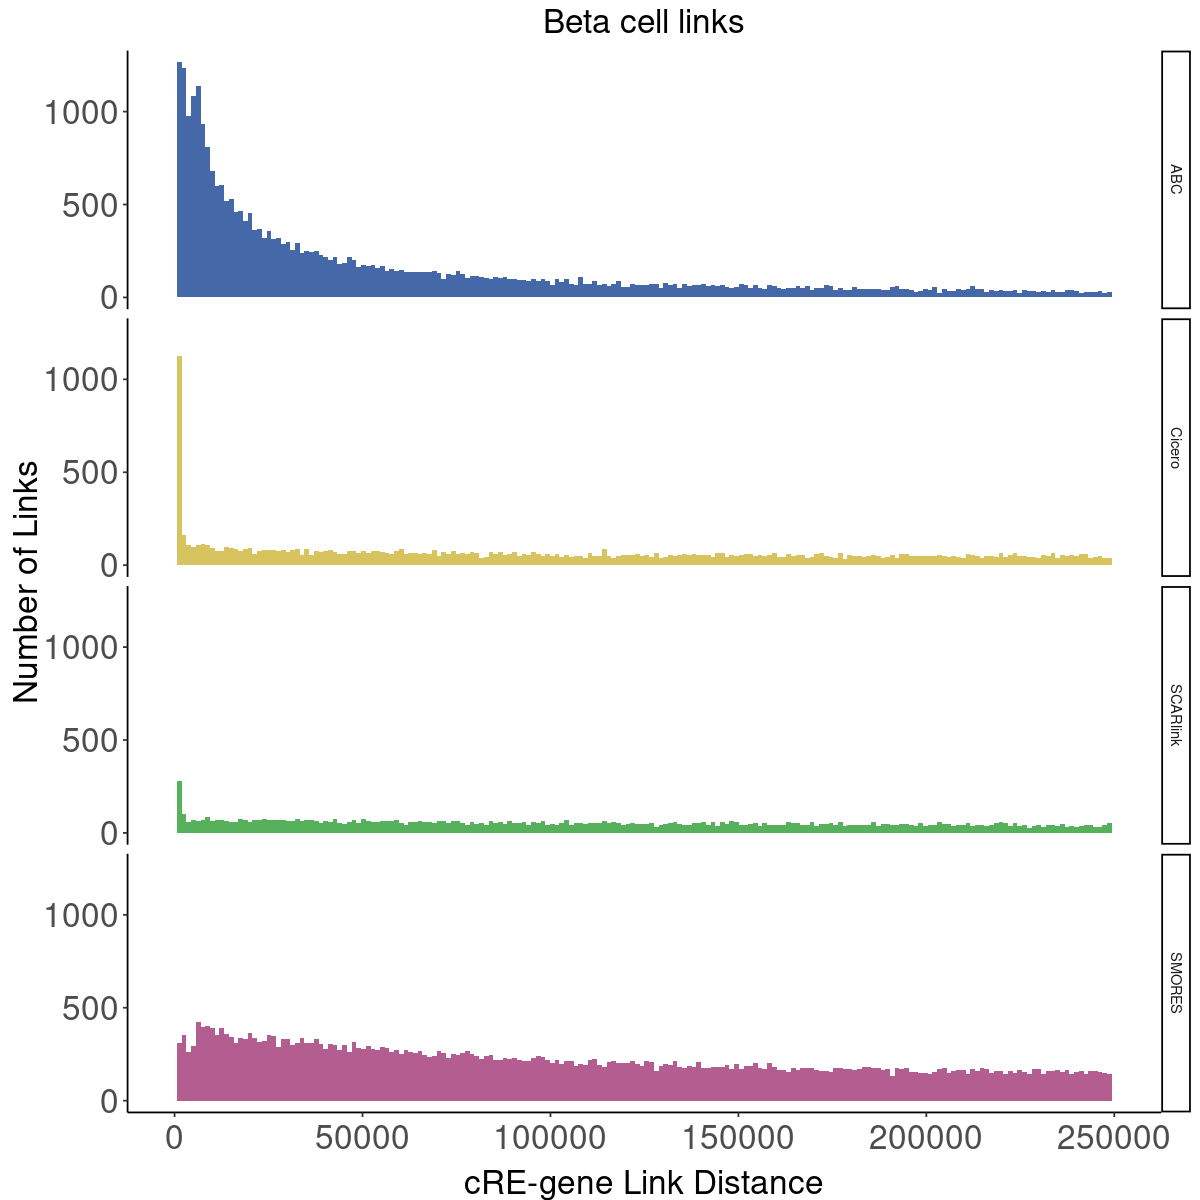

Warning message:
"Removed 8 rows containing missing values (`geom_bar()`)."


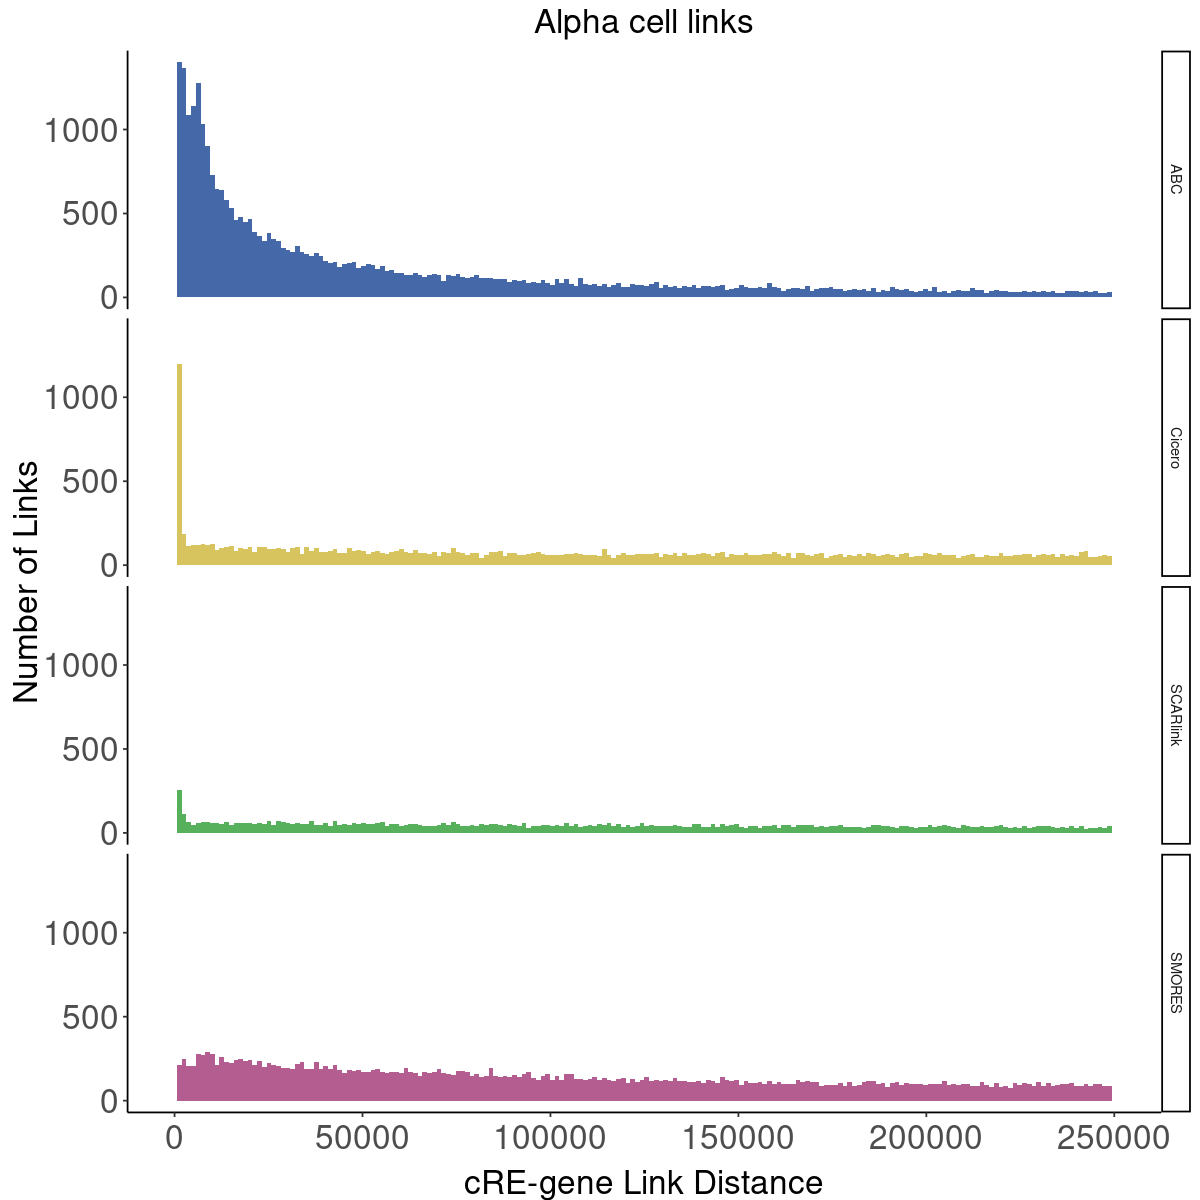

Warning message:
"Removed 8 rows containing missing values (`geom_bar()`)."


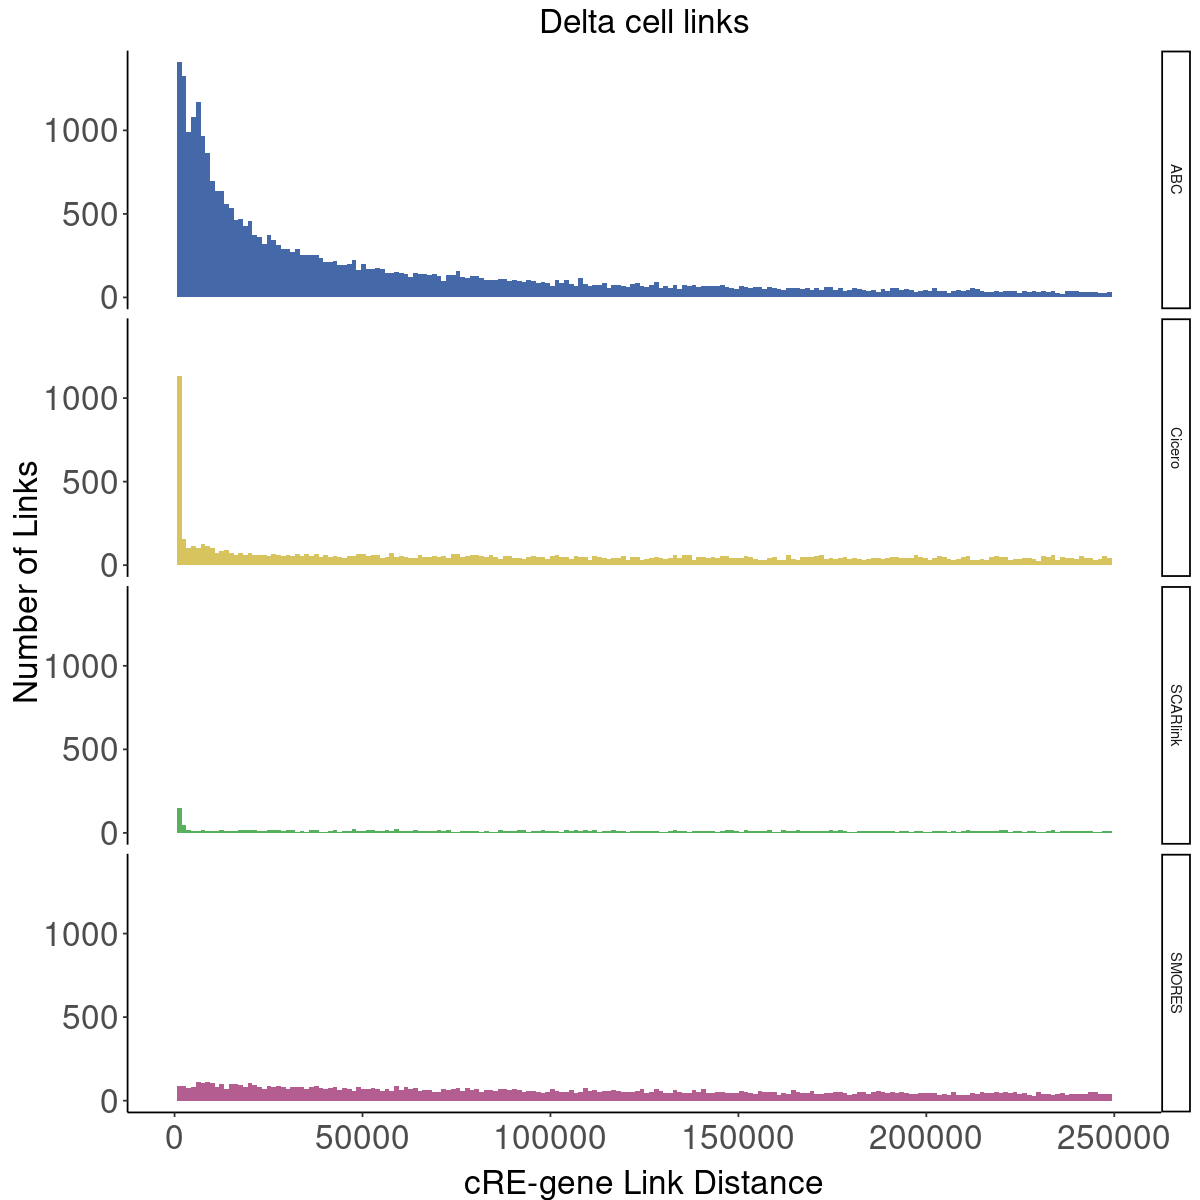

Warning message:
"Removed 8 rows containing missing values (`geom_bar()`)."


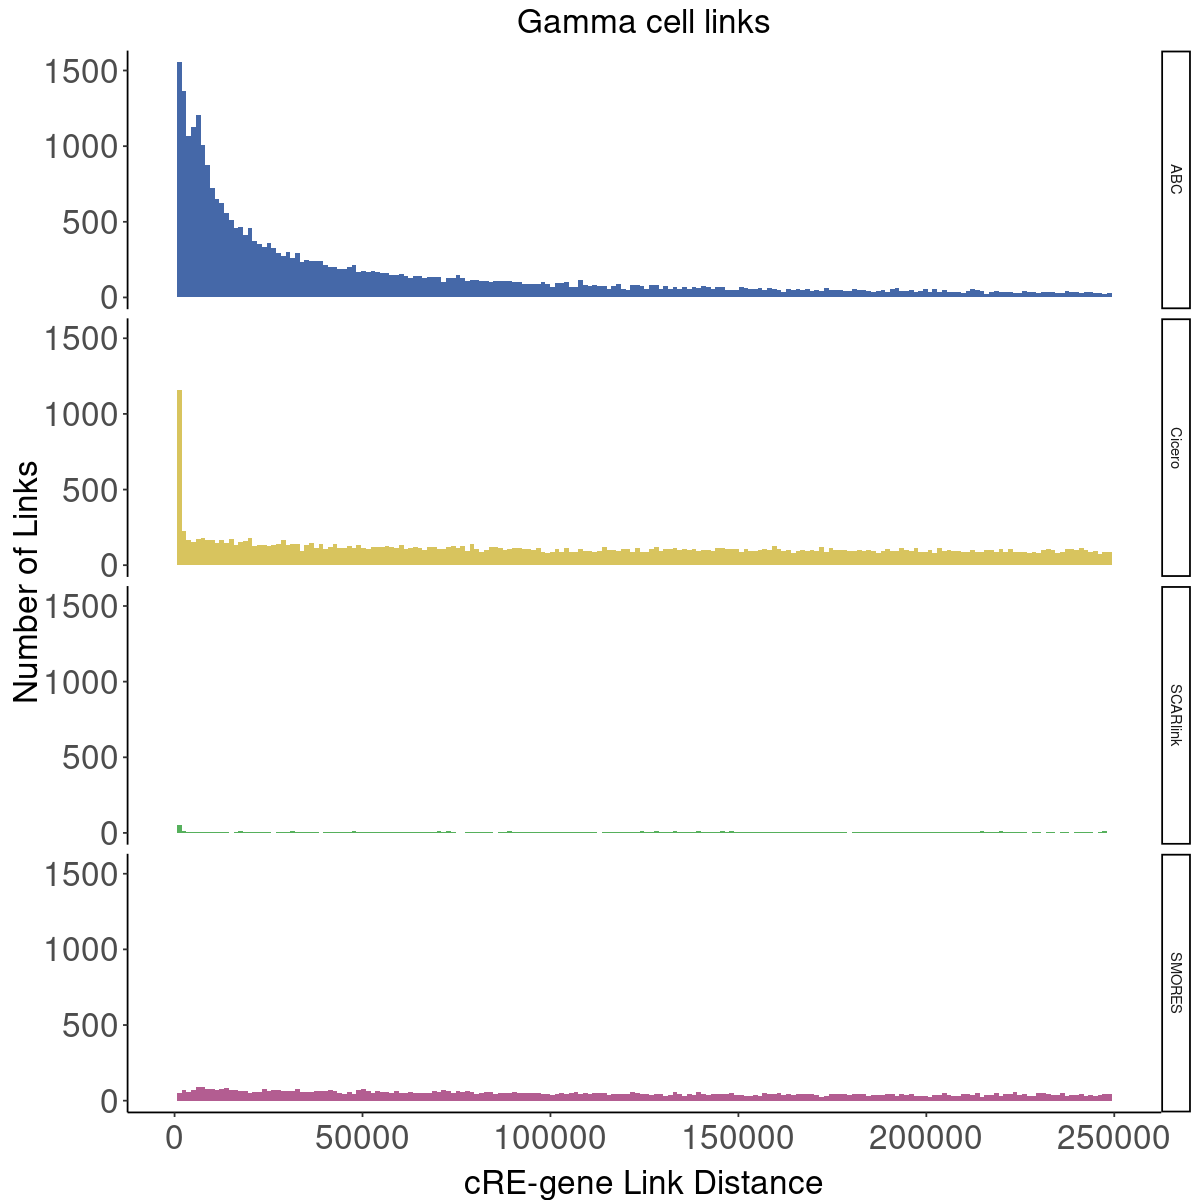

Warning message:
"Removed 2 rows containing non-finite values (`stat_bin()`)."
Warning message:
"Removed 8 rows containing missing values (`geom_bar()`)."


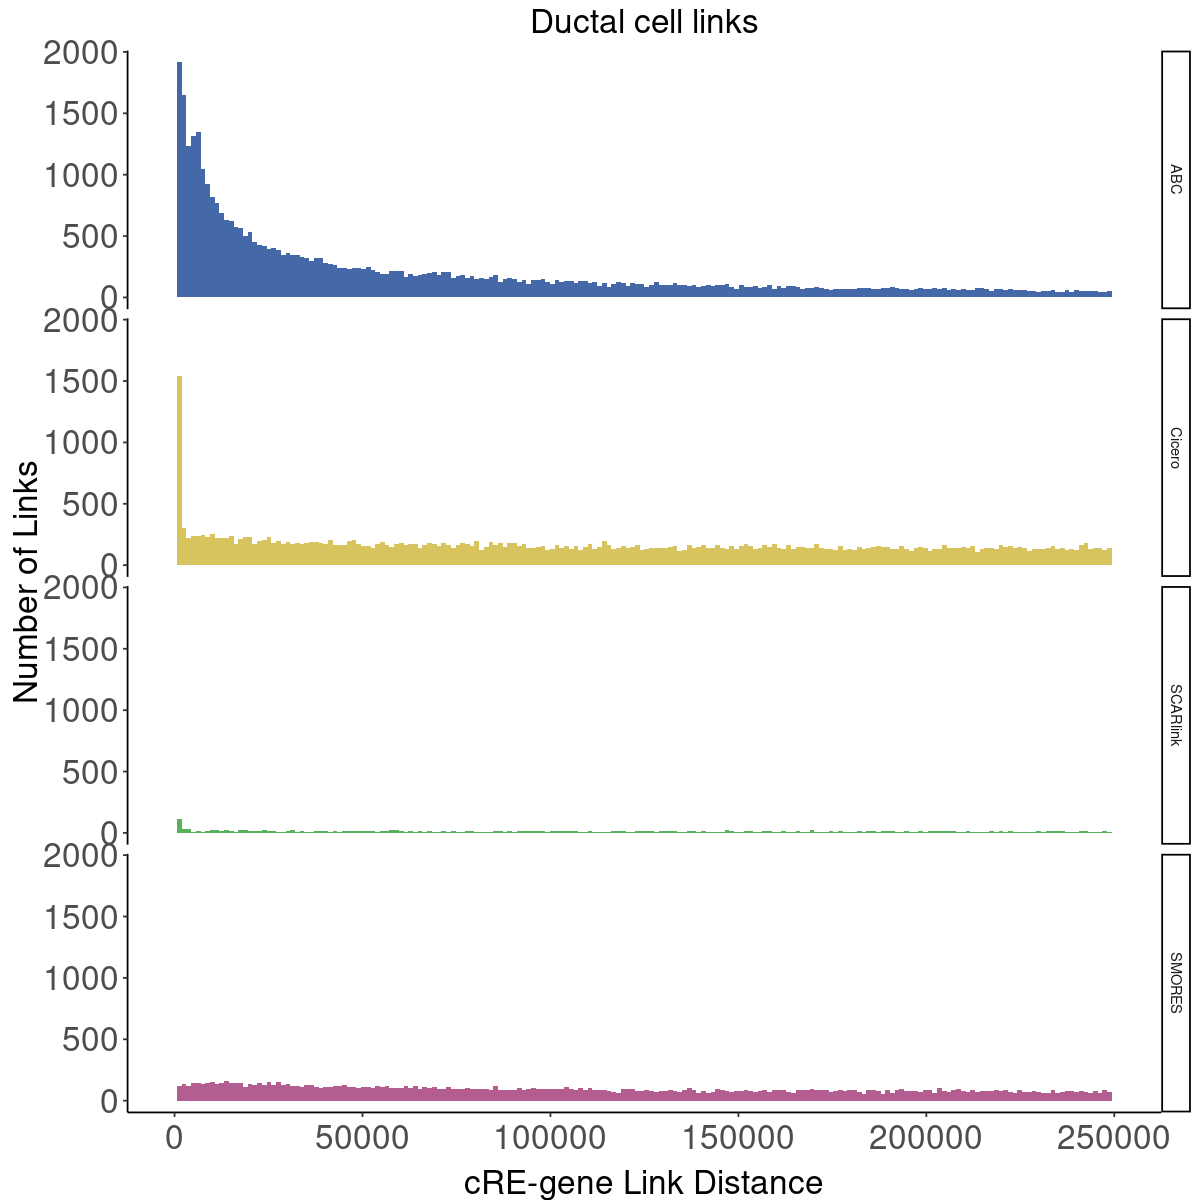

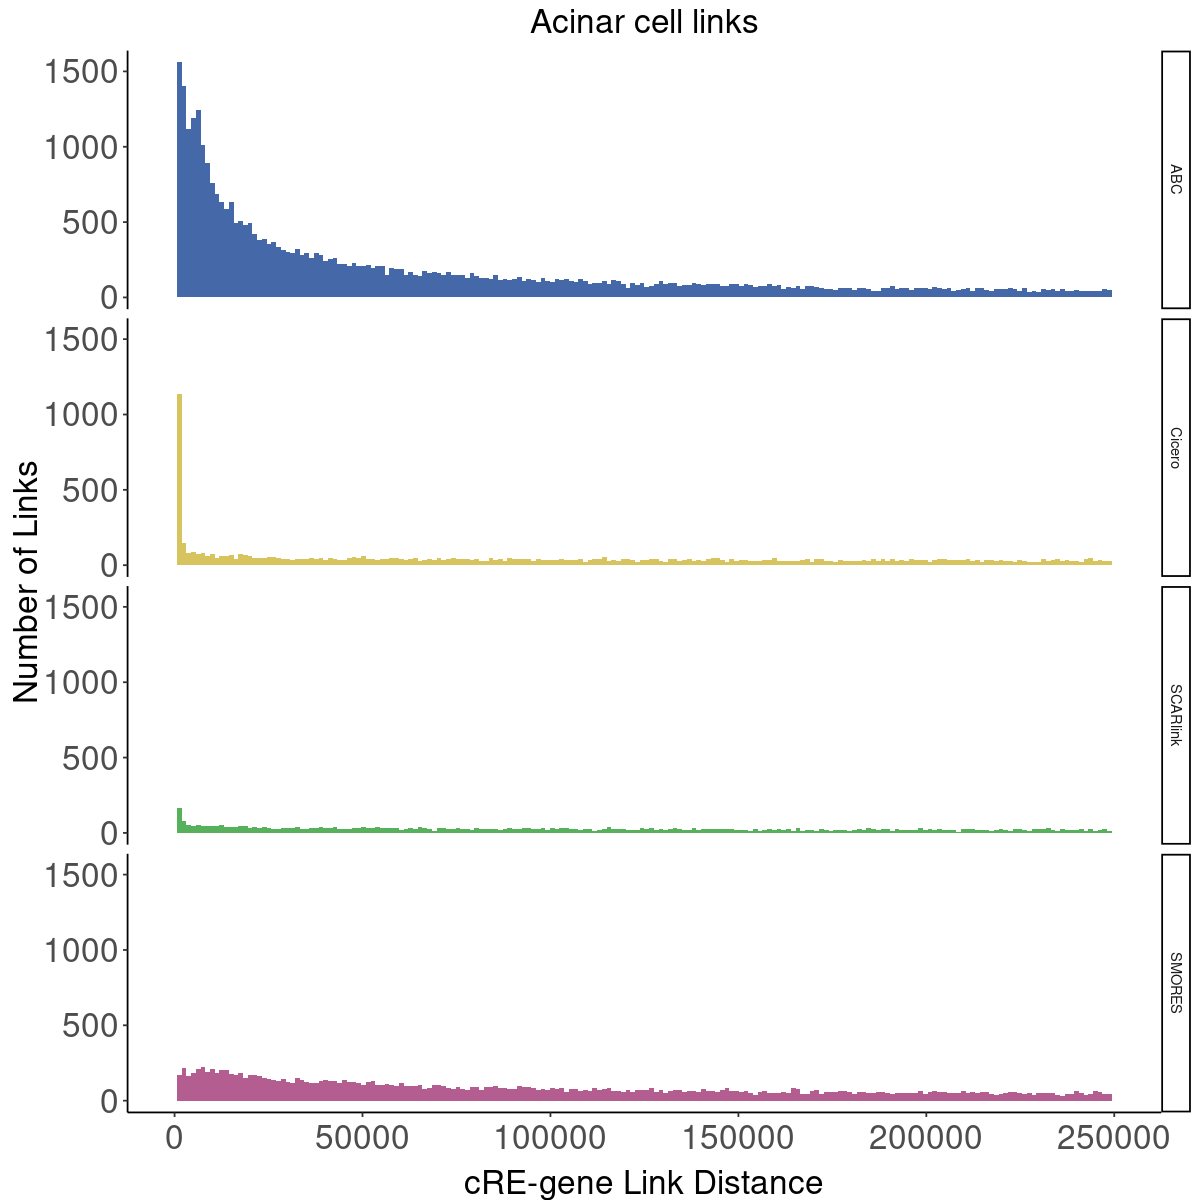

In [17]:
for (celltype in celltypes){
    sm_fp <- paste0(sm_prefix1,celltype,sm_suffix1)
    sl_fp <- paste0(sl_prefix,celltype,sl_suffix1)
    abc_fp <- paste0(abc_prefix1,celltype,abc_suffix1)
    cic_fp <- paste0(cic_prefix1,celltype,cic_suffix1)
    compare_distance_distribs(celltype, sm_fp, sl_fp, abc_fp, cic_fp, method_colors, c(0,250000))
}

# 3a. Overlap Link Sets with Upset Plots
Overlaps links sets with Upset and make an upset plot. Then write files containing all links in each overlap combinations.

### Functions

In [18]:
### Function to process links into a common format list
get_formatted_links <- function(row){
    cre = paste(row[[1]],row[[2]],row[[3]],sep='-')
    gene = row[[7]]
    return(paste(cre,gene,sep="_"))
}

In [49]:
### Function to compare the celltype links from 3 methods using an Upset plot
compare_links_plots <- function(celltype, colors){
    # Set up file paths for each links set
    sm_fp <- paste0(sm_prefix1,celltype,sm_suffix1)
    sl_fp <- paste0(sl_prefix,celltype,sl_suffix1)
    abc_fp <- paste0(abc_prefix1,celltype,abc_suffix1)
    cic_fp <- paste0(cic_prefix1,celltype,cic_suffix1)
    
    # Read in links and convert to basic format
    sm_df <- read.table(sm_fp, sep='\t')
    sm_links <- gsub(" ","",apply(sm_df, 1, get_formatted_links))
    sl_df <- read.table(sl_fp, sep='\t')
    sl_links <- gsub(" ","",apply(sl_df, 1, get_formatted_links))
    abc_df <- read.table(abc_fp, sep='\t')
    abc_links <- gsub(" ","",apply(abc_df, 1, get_formatted_links))
    cic_df <- read.table(cic_fp, sep='\t')
    cic_links <- gsub(" ","",apply(cic_df, 1, get_formatted_links))
    listInput <- list(smores = sm_links, scarlink = sl_links, abc = abc_links, cic=cic_links)
    
    # Get color order for Upset plot first
    overlap_key <- c('1111'='sm_sl_abc_cic',
                 '1110'='sm_sl_abc', '1101'='sm_sl_cic', '1011'='sm_abc_cic', '0111'='sl_abc_cic',
                 '1100'='sm_sl', '1010'='sm_abc', '1001'='sm_cic', '0110'='sl_abc', '0101'='sl_cic', '0011'='abc_cic',
                 '1000'='sm', '0100'='sl', '0010'='abc', '0001'='cic')
    overlaps <- upset(fromList(listInput), order.by="degree")$New_data
    overlaps <- overlaps %>% mutate(bin_code=paste0(smores,scarlink,abc,cic)) %>%
                    mutate(methods=overlap_key[bin_code]) %>%
                    group_by(methods) %>%
                    summarize(n=n()) %>% arrange(-n) %>%
                    mutate(colors=colors[methods])
    upset_colors <- overlaps$colors
    
    # Make Upset plot object
    options(repr.plot.width = 10, repr.plot.height = 6)
    p1 <- upset(fromList(listInput), order.by = "freq", sets.x.label="Links datasets",
                text.scale=c(1.5,1.5,1.5,1.5,2,2), point.size=5, line.size=2, main.bar.color=upset_colors)
    print(p1)
    title <- sprintf('%s links overlaps',celltype)
    grid.text(title, x=0.6, y=0.95, gp=gpar(fontsize=20))
}

### Run functions to overlap cRE-gene links sets and make outputs

In [34]:
black_colors <- rep('#000000', 15)
colors <- c('sm_sl_abc_cic'='#000000',
            'sl_abc_cic'='#6E9183',
            'sm_sl_cic'='#A58C77',
            'sm_sl_abc'='#81758A',
            'sm_abc_cic'='#867D90',
            'sl_cic'='#97BA5D',
            'sl_abc'='#4E8C82',
            'abc_cic'='#8F9683',
            'sm_sl'='#858777',
            'sm_cic'='#C69178',
            'sm_abc'='#7C639D',
            'sl'='#56B05C',
            'cic'='#D8C45E',
            'abc'='#4568A8',
            'sm'='#B35D91')

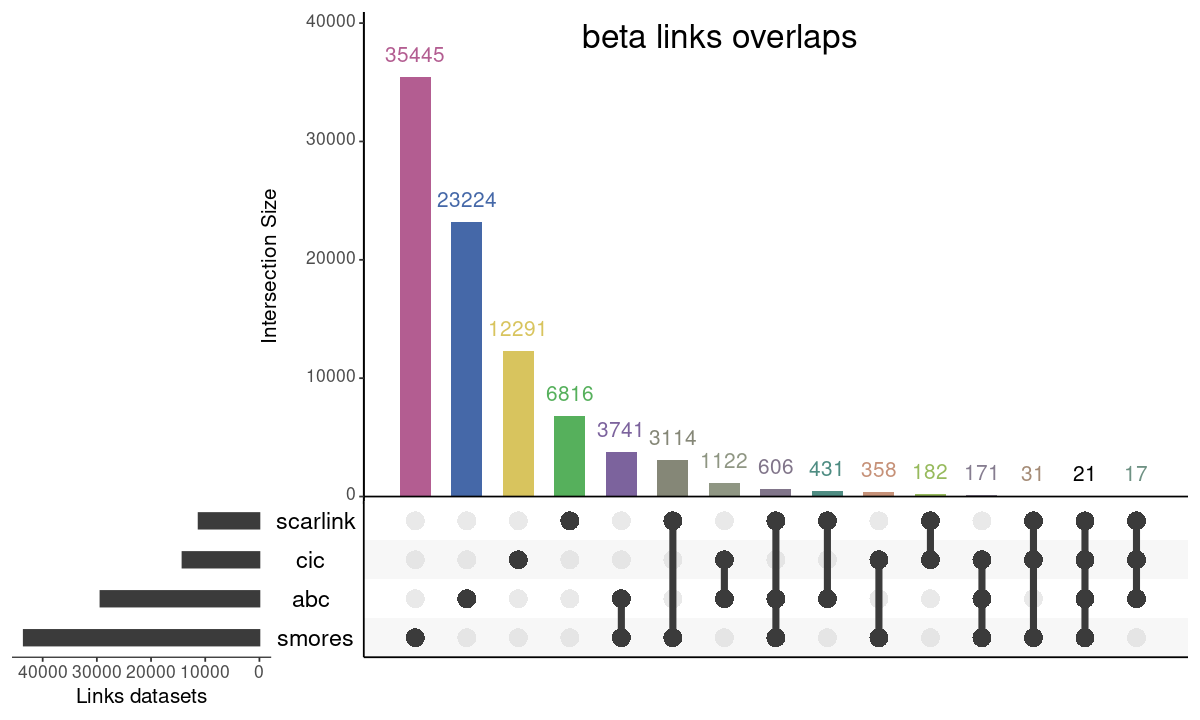

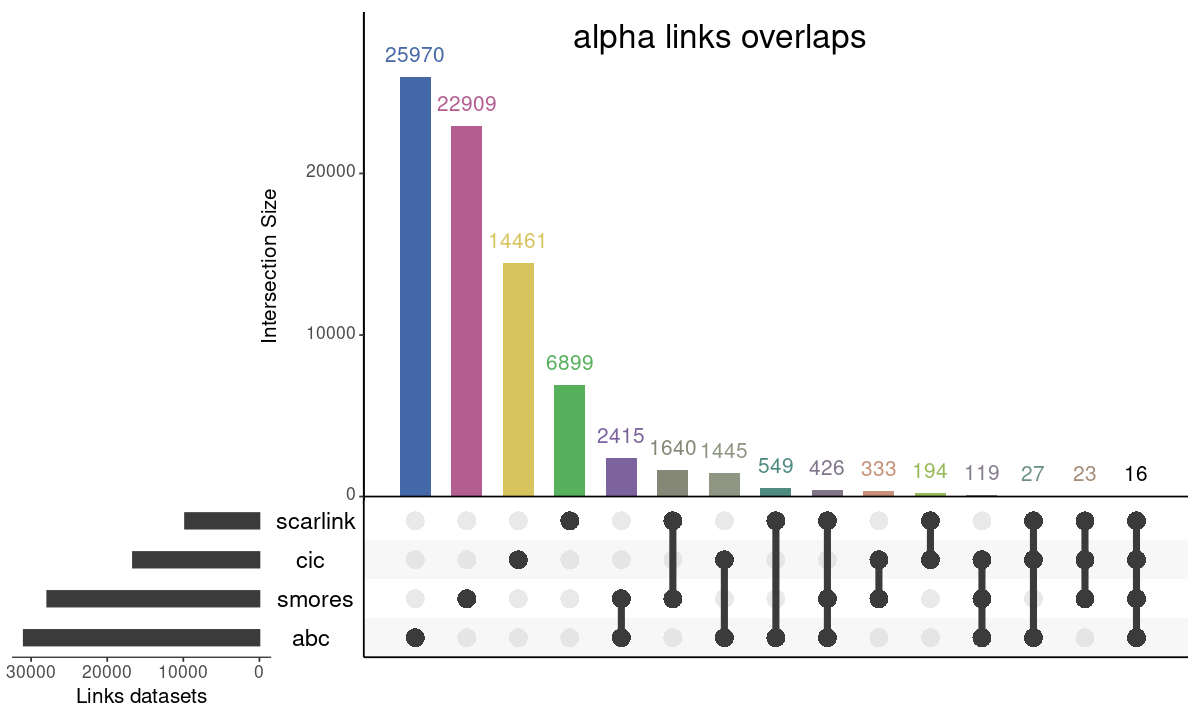

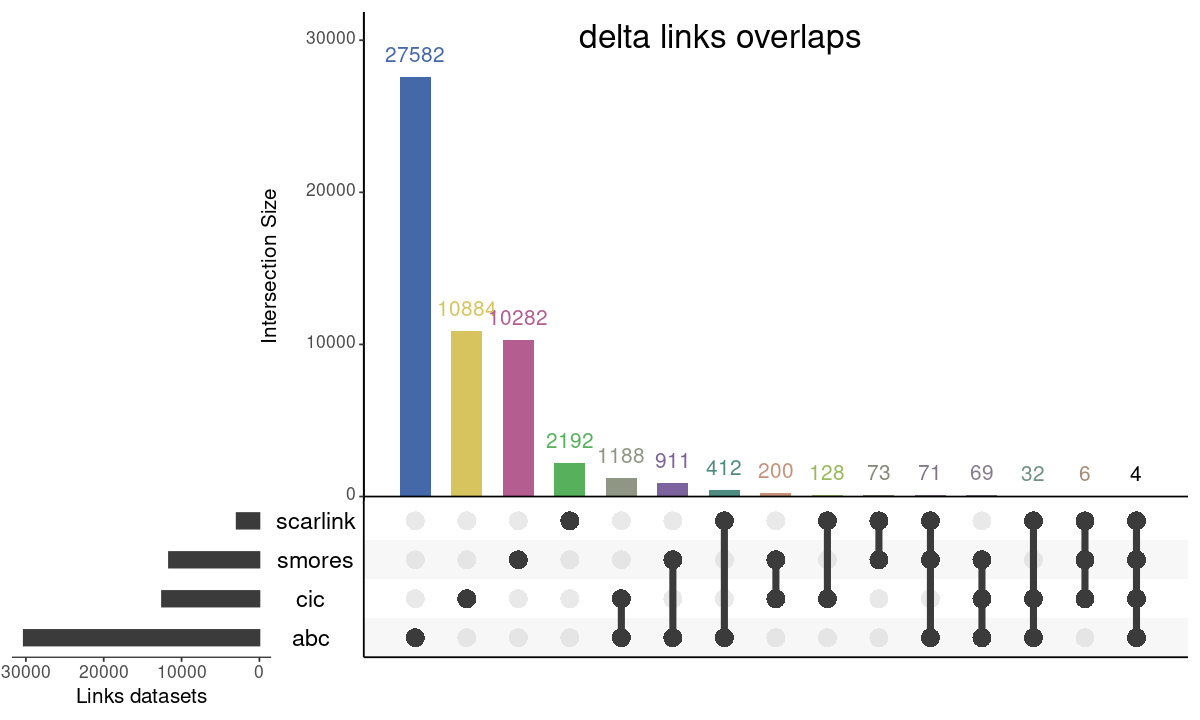

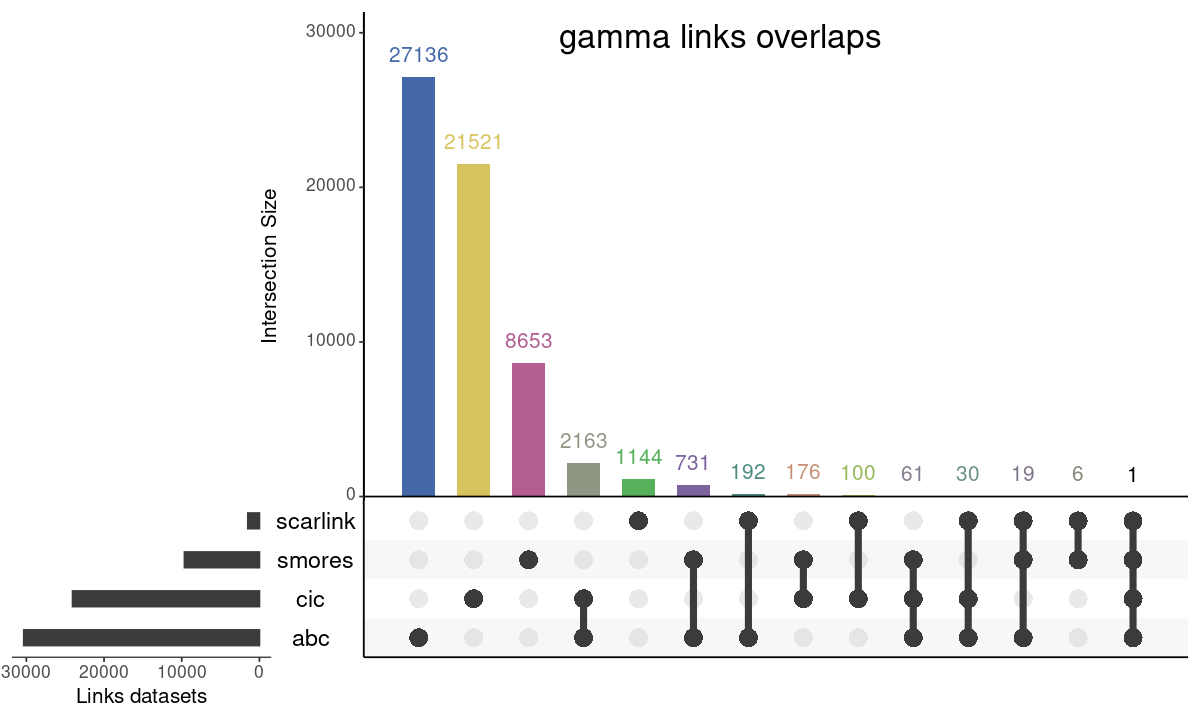

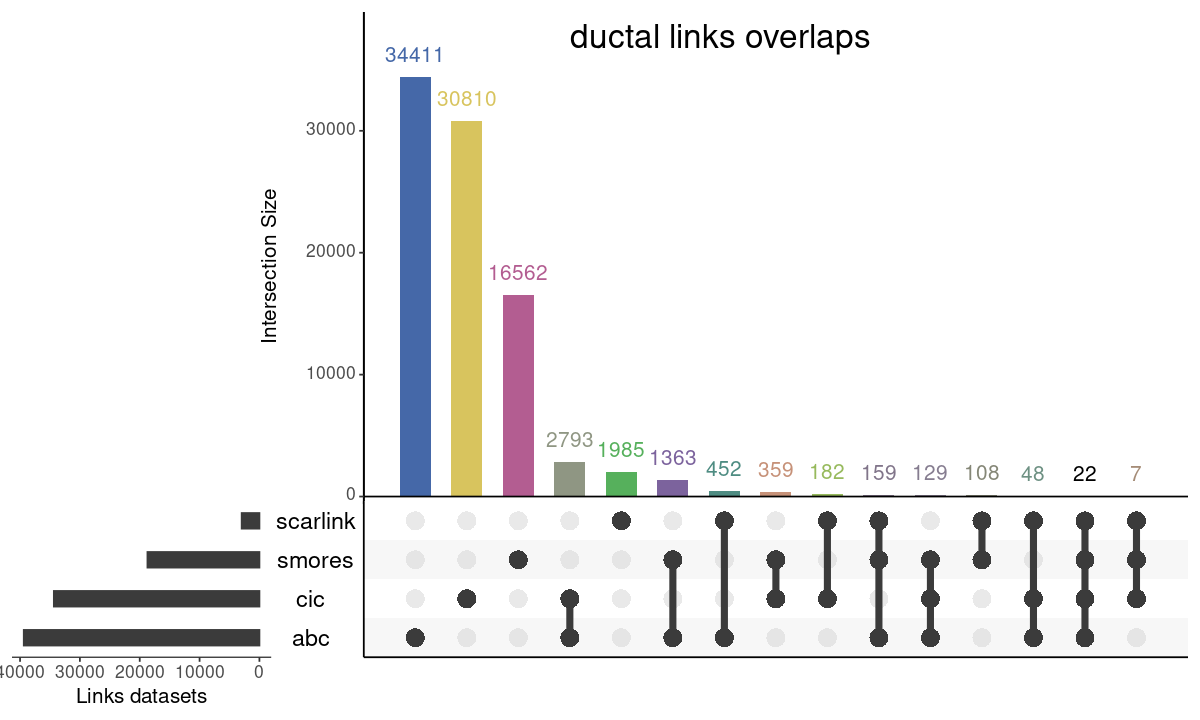

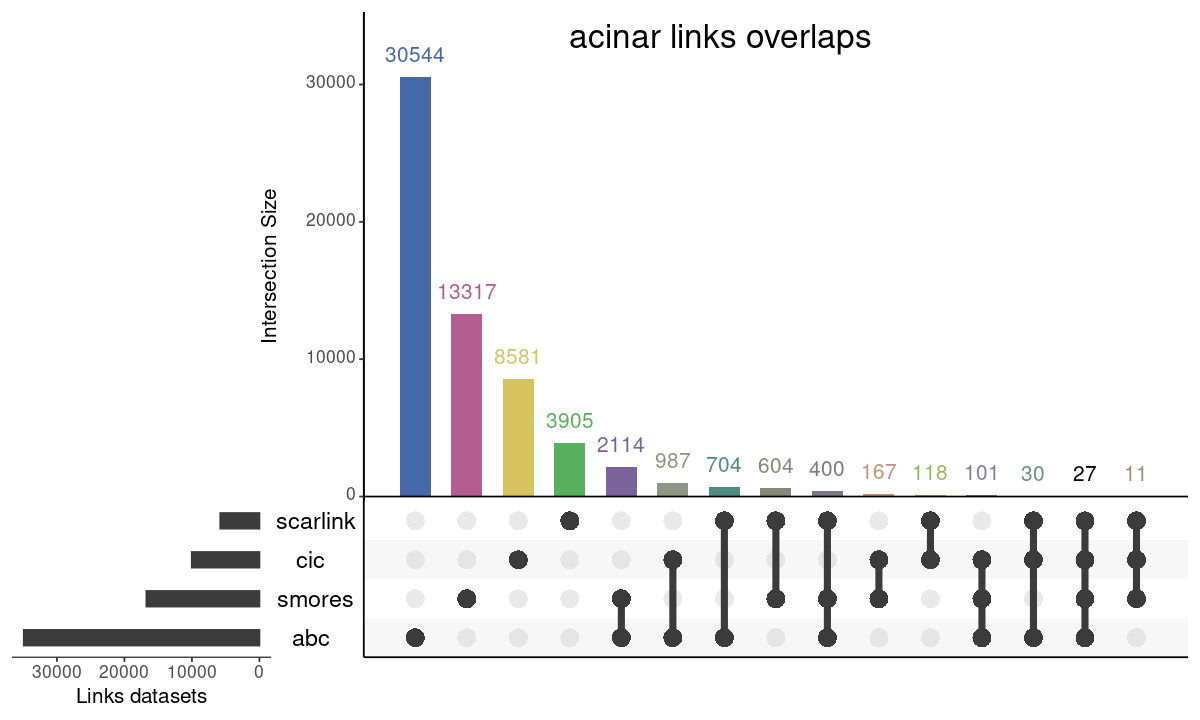

In [50]:
for (celltype in celltypes){
    compare_links_plots(celltype, colors)
}

In [2]:
sessionInfo()

R version 4.1.1 (2021-08-10)
Platform: x86_64-pc-linux-gnu (64-bit)
Running under: Ubuntu 20.04.2 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/blas/libblas.so.3.9.0
LAPACK: /usr/lib/x86_64-linux-gnu/lapack/liblapack.so.3.9.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
 [1] splines   stats4    grid      stats     graphics  grDevices utils    
 [8] datasets  methods   base     

other attached packages:
 [1] RColorBrewer_1.1-3   pheatmap_1.0.12      cicero_1.12.0       
 [4] Gviz_1.38.4          GenomicRanges_1.46.1 GenomeInfoDb_1.30.1 
 [7] IRanges_2.28.0       S4Vectors_0.32.4     monocle_2.22.0      
[10] DDRTree_0.1.5        ir